# Exploración y limpieza de datos

## Configuración del path

In [29]:
# Configuración del path del proyecto
# Permite importar módulos desde la carpeta raíz `Data-science`
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

# Se agrega la raíz del proyecto si aún no está incluida.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## Importacion de librerias

In [30]:
import pandas as pd
from src.labeling import map_sentiment
from src.text_preprocessing import normalize_text, remove_stopwords
import matplotlib.pyplot as plt

## Importación del dataset

In [ ]:
# Importación del dataset
ruta = PROJECT_ROOT/'data'/'1_raw_data.csv'

# Leer el archivo
try:
    df = pd.read_csv(ruta, encoding='latin1', engine='python', on_bad_lines='skip')
    # Mostrar las primeras filas para verificar
    print("Archivo cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {ruta}")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Archivo cargado exitosamente.


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Análisis inicial del dataset

In [32]:
# Selección de variables relevantes

# Para el análisis de sentimiento se seleccionan únicamente las columnas necesarias:
# Text → comentario completo del cliente (input del modelo)
# Score → calificación (usada para construir la etiqueta de sentimiento)

df = df[["Text", "Score"]]

# Verificación de número de filas con valores nulos
df.isnull().sum()


Text     0
Score    0
dtype: int64

In [33]:
# Construcción de la variable objetivo (Sentimiento) con la funcion map_sentiment
df["sentiment"] = df["Score"].apply(map_sentiment)

# Mostrar el dataset con la columna creada
df

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative
2,This is a confection that has been around a fe...,4,Positive
3,If you are looking for the secret ingredient i...,2,Negative
4,Great taffy at a great price. There was a wid...,5,Positive
...,...,...,...
568449,Great for sesame chicken..this is a good if no...,5,Positive
568450,I'm disappointed with the flavor. The chocolat...,2,Negative
568451,"These stars are small, so you can give 10-15 o...",5,Positive
568452,These are the BEST treats for training and rew...,5,Positive


In [34]:
# Proporcion de cada sentimiento
df["sentiment"].value_counts(normalize=True)


sentiment
Positive    0.780674
Negative    0.144316
Neutral     0.075010
Name: proportion, dtype: float64

sentiment  Negative  Neutral  Positive
Score                                 
1             52268        0         0
2             29769        0         0
3                 0    42640         0
4                 0        0     80655
5                 0        0    363122


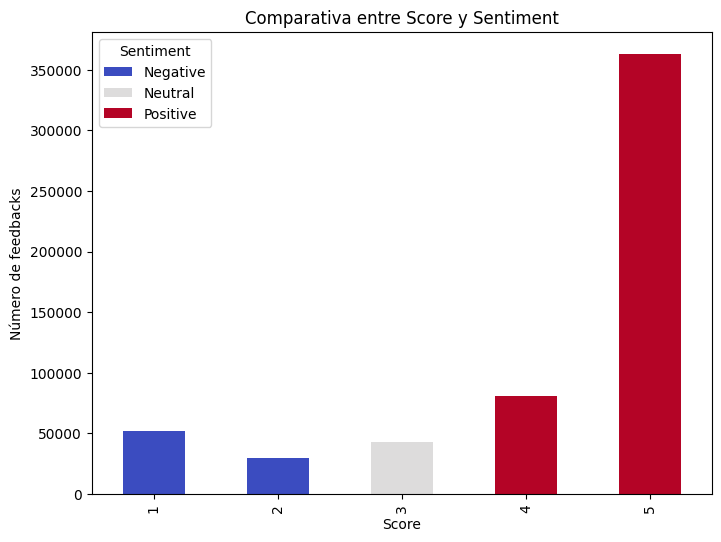

In [35]:
# Tabla comparativa entre Score y Sentiment
comparativa = pd.crosstab(df['Score'], df['sentiment'])

print(comparativa)

# Gráfico de barras apiladas
comparativa.plot(kind='bar', stacked=True, figsize=(8,6), colormap="coolwarm")
plt.title("Comparativa entre Score y Sentiment")
plt.xlabel("Score")
plt.ylabel("Número de feedbacks")
plt.legend(title="Sentiment")
plt.show()

## Limpieza y normalización del texto

In [ ]:
# Creacion de columna con texto limpio utilizando la funcion normalize_text
df["clean_text"] = df["Text"].astype(str).apply(normalize_text)

In [ ]:
# Eliminación de stopwords
# Se conservan únicamente palabras relevantes para expresar opinión y emoción.
df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [38]:
# Mostrar el dataset limpio
df

,Text,Score,sentiment,clean_text
0,I have bought several of the Vitality canned d...,5,Positive,bought vitality canned dog food products good ...
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,4,Positive,confection centuries light pillowy citrus gela...
3,If you are looking for the secret ingredient i...,2,Negative,looking secret ingredient robitussin believe g...
4,Great taffy at a great price. There was a wid...,5,Positive,great taffy great price wide assortment yummy ...
...,...,...,...,...
568449,Great for sesame chicken..this is a good if no...,5,Positive,great sesame chickenthis good better resturant...
568450,I'm disappointed with the flavor. The chocolat...,2,Negative,im disappointed flavor chocolate notes especia...
568451,"These stars are small, so you can give 10-15 o...",5,Positive,stars small training session tried train dog c...
568452,These are the BEST treats for training and rew...,5,Positive,best treats training rewarding dog good groomi...


## Dataset final

Se exporta el dataset final, que será utilizado en los procesos de Análisis Exploratorio de Datos y para el entrenamiento del modelo. Este datset tiene 3 columnas:
- Columna *Text*: se refiere al texto original, sin limpiar, que será utilizado para el entrenamiento del modelo.
- Columna *clean_text*: se refiere al texto limpio, se utilizará para realizar el Análisis Exploratorio de Datos, para identificar patrones en el texto limpio.
- Columna *sentiment*: se refiere a la clasificación del sentimiento del comentario, según sea positivo, negativo o neutro. Esta clasificación se basó en el score del comentario.

In [39]:
# Elección de columnas de texto limpio y el sentimiento.
df_final = df[["Text", "clean_text", "sentiment"]].copy()
df_final.head()


,Text,clean_text,sentiment
0,I have bought several of the Vitality canned d...,bought vitality canned dog food products good ...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,Negative
2,This is a confection that has been around a fe...,confection centuries light pillowy citrus gela...,Positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe g...,Negative
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,Positive


In [ ]:
# Exportación del dataset limpio
df_final.to_csv(PROJECT_ROOT/'data'/'2_clean_data.csv', index = False)